ПОИСК АССОЦИАТИВНЫХ ПРАВИЛ — APRIORI
Количество транзакций: 7501
Количество различных товаров: 115
Порог поддержки: 0%
Найдено частых наборов: 6938
Время Apriori: 72.950281 с

ПРАВИЛА ПРИ CONFIDENCE >= 70%
1. {грибной соус, эскалоп} -> {макароны} | support = 0.0043 | confidence = 0.7442
2. {замороженные овощи, молоко, суп} -> {минеральная вода} | support = 0.0031 | confidence = 0.7667
3. {макароны, растительное масло, яйца} -> {минеральная вода} | support = 0.0031 | confidence = 0.7188
4. {замороженные овощи, оливковое масло, шоколад} -> {минеральная вода} | support = 0.0028 | confidence = 0.7000
5. {молоко, оливковое масло, яйца} -> {минеральная вода} | support = 0.0027 | confidence = 0.7143
6. {говяжий фарш, замороженные овощи, креветки} -> {макароны} | support = 0.0025 | confidence = 0.7917
7. {макароны, обезжиренное молоко} -> {минеральная вода} | support = 0.0025 | confidence = 0.7308
8. {блинчики, макароны, суп} -> {минеральная вода} | support = 0.0023 | confidence = 0.7727
9. {б

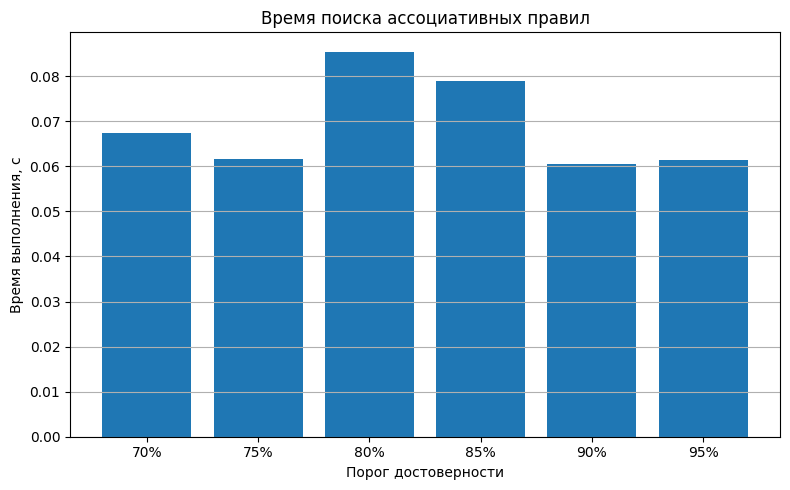

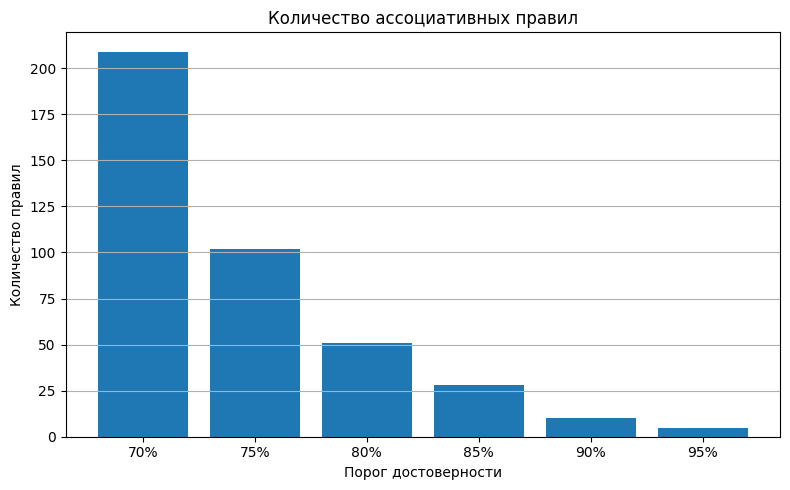


Созданы файлы:
rules.csv
rules_limited_7.csv
rule_experiments.csv
rule_time_vs_confidence.png
rule_count_vs_confidence.png


In [5]:
import csv
import itertools
import math
import time
from collections import Counter
import matplotlib.pyplot as plt


DATA_FILE = "baskets.csv"
MIN_SUPPORT = 0.001
CONFIDENCE_VALUES = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
SORT_BY = "support"

RULES_FILE = "rules.csv"
LIMITED_RULES_FILE = "rules_limited_7.csv"
EXPERIMENTS_FILE = "rule_experiments.csv"
TIME_CHART_FILE = "rule_time_vs_confidence.png"
COUNT_CHART_FILE = "rule_count_vs_confidence.png"


def read_data(filename):
    with open(filename, encoding="cp1251", newline="") as f:
        return [
            {x.strip() for x in row if x.strip()}
            for row in csv.reader(f)
            if any(x.strip() for x in row)
        ]


def apriori(transactions, min_support, sort_by="support"):
    n = len(transactions)
    min_count = math.ceil(n * min_support)

    counts = Counter(
        item for basket in transactions for item in basket
    )

    current = {
        frozenset([item]): count
        for item, count in counts.items()
        if count >= min_count
    }

    result = dict(current)
    k = 2

    while current:
        previous = set(current)
        candidates = set()

        for a, b in itertools.combinations(previous, 2):
            candidate = a | b

            if len(candidate) == k and all(
                frozenset(s) in previous
                for s in itertools.combinations(candidate, k - 1)
            ):
                candidates.add(candidate)

        if not candidates:
            break

        counts = Counter(
            candidate
            for basket in transactions
            for candidate in candidates
            if candidate.issubset(basket)
        )

        current = {
            candidate: count
            for candidate, count in counts.items()
            if count >= min_count
        }

        result.update(current)
        k += 1

    if sort_by == "support":
        result = sorted(
            result.items(),
            key=lambda x: (-x[1] / n, tuple(sorted(x[0])))
        )
    else:
        result = sorted(
            result.items(),
            key=lambda x: tuple(sorted(x[0]))
        )

    return [
        (tuple(sorted(items)), count / n)
        for items, count in result
    ]


def generate_rules(frequent_itemsets, min_confidence, sort_by="support"):
    support = {
        frozenset(items): value
        for items, value in frequent_itemsets
    }

    rules = []

    for itemset, itemset_support in frequent_itemsets:
        itemset = frozenset(itemset)

        if len(itemset) < 2:
            continue

        items = sorted(itemset)

        for size in range(1, len(items)):
            for values in itertools.combinations(items, size):
                antecedent = frozenset(values)
                consequent = itemset - antecedent

                if antecedent not in support:
                    continue

                confidence = itemset_support / support[antecedent]

                if confidence >= min_confidence:
                    rules.append({
                        "antecedent": tuple(sorted(antecedent)),
                        "consequent": tuple(sorted(consequent)),
                        "support": itemset_support,
                        "confidence": confidence,
                        "total_items": len(itemset)
                    })

    unique = {}

    for rule in rules:
        key = (
            rule["antecedent"],
            rule["consequent"]
        )
        unique[key] = rule

    rules = list(unique.values())

    if sort_by == "support":
        rules.sort(
            key=lambda r: (
                -r["support"],
                -r["confidence"],
                r["antecedent"],
                r["consequent"]
            )
        )
    else:
        rules.sort(
            key=lambda r: (
                r["antecedent"],
                r["consequent"]
            )
        )

    return rules


def save_rules(rules, filename):
    with open(
        filename,
        "w",
        encoding="utf-8-sig",
        newline=""
    ) as f:
        writer = csv.writer(f)

        writer.writerow([
            "Антецедент",
            "Консеквент",
            "Поддержка",
            "Достоверность",
            "Всего объектов"
        ])

        for rule in rules:
            writer.writerow([
                ", ".join(rule["antecedent"]),
                ", ".join(rule["consequent"]),
                f"{rule['support']:.6f}",
                f"{rule['confidence']:.6f}",
                rule["total_items"]
            ])


def run_experiments(frequent_itemsets):
    results = []

    for confidence in CONFIDENCE_VALUES:
        start = time.perf_counter()

        rules = generate_rules(
            frequent_itemsets,
            confidence,
            SORT_BY
        )

        elapsed = time.perf_counter() - start

        results.append({
            "support": MIN_SUPPORT,
            "confidence": confidence,
            "time": elapsed,
            "count": len(rules)
        })

    return results


def save_experiments(results):
    with open(
        EXPERIMENTS_FILE,
        "w",
        encoding="utf-8-sig",
        newline=""
    ) as f:
        writer = csv.writer(f)

        writer.writerow([
            "Порог поддержки",
            "Порог достоверности",
            "Время, с",
            "Количество правил"
        ])

        for r in results:
            writer.writerow([
                r["support"],
                r["confidence"],
                r["time"],
                r["count"]
            ])


def make_charts(results):
    x = [
        f"{r['confidence'] * 100:.0f}%"
        for r in results
    ]

    plt.figure(figsize=(8, 5))
    plt.bar(
        x,
        [r["time"] for r in results]
    )
    plt.xlabel("Порог достоверности")
    plt.ylabel("Время выполнения, с")
    plt.title("Время поиска ассоциативных правил")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(TIME_CHART_FILE, dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(
        x,
        [r["count"] for r in results]
    )
    plt.xlabel("Порог достоверности")
    plt.ylabel("Количество правил")
    plt.title("Количество ассоциативных правил")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.savefig(COUNT_CHART_FILE, dpi=300)
    plt.show()


def print_rules(rules, title, limit=50):
    print()
    print("=" * 80)
    print(title)
    print("=" * 80)

    if not rules:
        print("Правил не найдено.")
        return

    for i, rule in enumerate(rules[:limit], 1):
        a = ", ".join(rule["antecedent"])
        c = ", ".join(rule["consequent"])

        print(
            f"{i}. {{{a}}} -> {{{c}}} | "
            f"support = {rule['support']:.4f} | "
            f"confidence = {rule['confidence']:.4f}"
        )


def main():
    transactions = read_data(DATA_FILE)

    print("=" * 70)
    print("ПОИСК АССОЦИАТИВНЫХ ПРАВИЛ — APRIORI")
    print("=" * 70)

    print(f"Количество транзакций: {len(transactions)}")

    items = set()
    for basket in transactions:
        items.update(basket)

    print(f"Количество различных товаров: {len(items)}")
    print(f"Порог поддержки: {MIN_SUPPORT * 100:.0f}%")

    start = time.perf_counter()

    frequent_itemsets = apriori(
        transactions,
        MIN_SUPPORT,
        SORT_BY
    )

    apriori_time = time.perf_counter() - start

    print(
        f"Найдено частых наборов: "
        f"{len(frequent_itemsets)}"
    )

    print(
        f"Время Apriori: "
        f"{apriori_time:.6f} с"
    )

    rules = generate_rules(
        frequent_itemsets,
        0.70,
        SORT_BY
    )

    print_rules(
        rules,
        "ПРАВИЛА ПРИ CONFIDENCE >= 70%"
    )

    save_rules(
        rules,
        RULES_FILE
    )

    limited_rules = [
        r for r in rules
        if r["total_items"] <= 7
    ]

    save_rules(
        limited_rules,
        LIMITED_RULES_FILE
    )

    print(
        f"\nПравил с количеством объектов <= 7: "
        f"{len(limited_rules)}"
    )

    results = run_experiments(
        frequent_itemsets
    )

    print()
    print("=" * 70)
    print("РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА")
    print("=" * 70)

    print(
        f"{'Confidence':<15}"
        f"{'Время, с':<15}"
        f"{'Правил':<15}"
    )

    for r in results:
        print(
            f"{r['confidence'] * 100:<15.0f}"
            f"{r['time']:<15.6f}"
            f"{r['count']:<15}"
        )

    save_experiments(results)
    make_charts(results)

    print()
    print("Созданы файлы:")
    print(RULES_FILE)
    print(LIMITED_RULES_FILE)
    print(EXPERIMENTS_FILE)
    print(TIME_CHART_FILE)
    print(COUNT_CHART_FILE)

    if not rules:
        print()
        print(
            "ВНИМАНИЕ: при выбранном пороге поддержки "
            "правила не найдены."
        )
        print(
            "Попробуйте уменьшить MIN_SUPPORT, например до 0.005."
        )


if __name__ == "__main__":
    main()

